In [9]:
import torch
import torch.nn as nn
import torch.optim as optim 
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt 


In [10]:
# creating batches
BATCH_SIZE = 128

data_transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    transform=data_transform,
    download=True
)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)


In [19]:
# coding the VAe class

latent_dim = 64


class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=256, latent_dim=latent_dim):
        super().__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)       # fc = fullyconnected
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)  # for mean
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # for log variance

        # Decoder
        self.fc2= nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)  # for reconstruction

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def encode(self, x):    
        h = self.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar



    def reparameterize(self, mu, logvar):    
        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)
        z= mu + eps*std
        return z


    def decode(self, x):
        h = self.relu(self.fc2(x))
        out = self.sigmoid(self.fc3(h))
        return out
    
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_reconstructed = self.decode(z)
        return x_reconstructed, mu, logvar
      

In [25]:
# coding the loss

def vae_loss(recon_x, x, mu,logvar):
    recon_loss = nn.functional.binary_cross_entropy(recon_x, x, reduction='sum')

    kl_loss= 0.5*torch.sum(mu**2 + logvar.exp() - logvar -1)

    return recon_loss + kl_loss


In [26]:
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [27]:
epochs = 6

model.train()

for epoch in range(epochs):
    total_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 784)

        optimizer.zero_grad()

        x_recon, mu, logvar = model(x)
        loss = vae_loss(x_recon, x, mu, logvar)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')

Epoch [1/6], Loss: 22984.8759
Epoch [2/6], Loss: 17114.9096
Epoch [3/6], Loss: 15663.8102
Epoch [4/6], Loss: 14900.8054
Epoch [5/6], Loss: 14499.6216
Epoch [6/6], Loss: 14261.6740


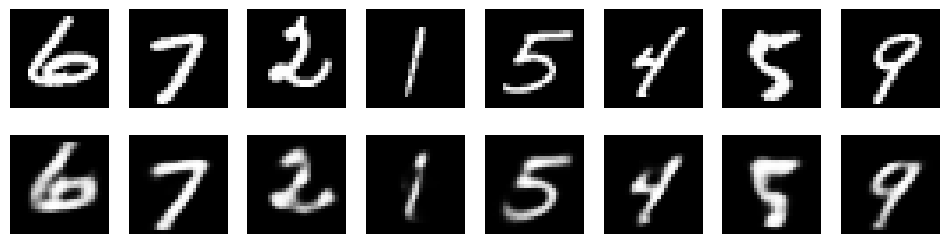

In [29]:
model.eval()

with torch.no_grad():
    x, _ = next(iter(train_loader))
    x = x.view(-1, 784)
    x_recon, _, _ = model(x)

# Visualize original and reconstructed images

x=x.cpu()
x_recon = x_recon.cpu()

n=8
plt.figure(figsize=(12, 3))
for i in range(n):
    # Original images
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28, 28), cmap='gray')
    plt.axis('off')

    # Reconstructed images
    plt.subplot(2, n, n+i+1)
    plt.imshow(x_recon[i].view(28, 28), cmap='gray')
    plt.axis('off')

plt.show()    